# Evaluation - Comparing CGAN and Conditional Diffusion 

## Plan

1. Understand how to measure the quality and diversity of generated data using **FID**.  
2. Compare **cGAN vs Diffusion** outputs visually and statistically.  
3. Train a downstream **handwriting classifier** using synthetic data.  
4. Assess which generative approach produces more *useful* data for CAPTCHA robustness.



### Objectives to check
+ Do the samples look human like 
+ we would measure the quantititative quality using Frechet Inception Distance 
+ Also work on using sythetic data from each model to train a useful classifier

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import inception_v3
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, sys
from scipy import linalg


from utils.visualize import show_batch
from utils.checkpoint import load_checkpoint
from torchmetrics.image.fid import FrechetInceptionDistance

We’ll now load both trained models — the **cGAN** and **Diffusion** generators —  
and use them to generate a fixed number of samples for evaluation.

In [2]:
from model.cgan import Generator
from model.diffusion import ConditionalUNet
from training.train_diffusion import sample_images

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Using device: {device}")



 Using device: cuda


In [13]:
# Helper Functions

from torchvision import datasets, transforms
def get_real_examples_per_class(n_classes=10):
    """
    Deterministically extracts one MNIST image per class (0–9)
    directly from the dataset without shuffle.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    mnist = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

    imgs, labels = [], []
    for cls in range(n_classes):
        for i in range(len(mnist)):
            if mnist[i][1] == cls:
                imgs.append(mnist[i][0])
                labels.append(cls)
                break  # stop at first match
    return torch.stack(imgs), torch.tensor(labels)




def get_representative_images(imgs, labels, n_classes=10):
    """
    Returns one representative image per class label (0–9).
    Ensures true label alignment for real datasets.
    """
    reps = []
    for i in range(n_classes):
        idx = (labels == i).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            reps.append(imgs[idx[0]])
        else:
            reps.append(torch.zeros_like(imgs[0]))  
    return torch.stack(reps)


@torch.no_grad()
def generate_conditioned_samples_cgan(generator, z_dim=100, device="cuda", n_classes=10):
    """
    Generate one representative sample per class (0–9) from cGAN.
    """
    generator.eval()
    zs = torch.randn(n_classes, z_dim, device=device)
    ys = torch.arange(n_classes, dtype=torch.long, device=device)
    imgs = generator(zs, ys).cpu()
    return imgs, ys.cpu()


@torch.no_grad()
def generate_conditioned_samples_diffusion(
    model,
    device="cuda",
    n_classes=10,
    timesteps=200,          # used same as training
    img_size=(1, 28, 28)
):
    """
    Generate one representative diffusion sample per class (0–9), 
    using the same sampling logic as training-time generation.
    """
    from training.train_diffusion import linear_beta_schedule
    model.eval()

    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, 0)

    imgs_list, labels_list = [], []

    for cls in range(n_classes):
        # Conditioning label for this class
        labels = torch.full((1,), cls, dtype=torch.long, device=device)
        imgs = torch.randn(1, *img_size).to(device)

        # Reverse diffusion loop (same as training sampler)
        for t in reversed(range(timesteps)):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.long)
            pred_noise = model(imgs, t_tensor, labels)
            alpha = alphas[t]
            alpha_bar = alphas_cumprod[t]

            # Predict next sample
            noise = torch.randn_like(imgs) if t > 0 else torch.zeros_like(imgs)
            imgs = (1 / torch.sqrt(alpha)) * (
                imgs - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
            ) + torch.sqrt(betas[t]) * noise

        imgs_list.append(imgs[0].cpu())
        labels_list.append(cls)

    imgs_tensor = torch.stack(imgs_list)
    labels_tensor = torch.tensor(labels_list)
    return imgs_tensor, labels_tensor


def plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10):
    """
    Visual comparison between Real, cGAN, and Diffusion images.
   
    """

    fig, axs = plt.subplots(3, n_classes, figsize=(12, 4))
    fig.suptitle(" Comparison: Real vs cGAN vs Diffusion", fontsize=14, fontweight="bold")

    row_titles = [
        "Ground Truth",
        "CGAN",
        "Diffusion"
    ]
    row_colors = ["green", "royalblue", "darkorange"]

    # Plot each row
    for row_idx, row_imgs in enumerate([real_imgs, cgan_imgs, diff_imgs]):
        for i in range(n_classes):
            axs[row_idx, i].imshow(row_imgs[i].squeeze(), cmap="gray")
            axs[row_idx, i].axis("off")
            axs[row_idx, i].set_title(f"Class {i}", fontsize=8, pad=2)

    # Manually place row labels on figure (not as axis labels)
    for idx, (title, color) in enumerate(zip(row_titles, row_colors)):
        fig.text(
            0.02,                                   # x-position (left margin)
            0.84 - idx * 0.32,                      # y-position per row
            title,
            fontsize=11,
            color=color,
            fontweight="bold",
            va="center"
        )

    plt.subplots_adjust(left=0.12, right=0.98, top=0.9, bottom=0.05, hspace=0.3)
    plt.show()

In [14]:


def compute_fid(real_imgs, fake_imgs, device="cuda", batch_size=128):
    """
    Compute FID safely in GPU batches to prevent OOM.
    Works with TorchMetrics' FrechetInceptionDistance.
    """
    fid = FrechetInceptionDistance(normalize=True).to(device)
    fid.reset()

    def batched_update(imgs, real_flag):
        for i in tqdm(range(0, imgs.size(0), batch_size), desc=f"FID {'real' if real_flag else 'fake'}"):
            batch = imgs[i:i + batch_size].to(device, non_blocking=True)
            fid.update(batch, real=real_flag)
            torch.cuda.empty_cache()


    real_imgs_rgb = (real_imgs.repeat(1, 3, 1, 1) + 1) / 2
    fake_imgs_rgb = (fake_imgs.repeat(1, 3, 1, 1) + 1) / 2
    real_imgs_rgb = torch.clamp(real_imgs_rgb, 0, 1)
    fake_imgs_rgb = torch.clamp(fake_imgs_rgb, 0, 1)

    batched_update(real_imgs_rgb, real_flag=True)
    batched_update(fake_imgs_rgb, real_flag=False)

    score = fid.compute().item()
    return score

In [15]:
# Safety clean up
torch.cuda.empty_cache()

In [16]:
device

'cuda'

In [17]:
# Load trained checkpoints (adjust path if different)
os.makedirs("../checkpoints", exist_ok=True)

#ToDo:  
   #1. Initialize cGAN Generator model
   #2. Initialize conditional UNet model
cgan_gen = Generator().to(device)
diff_model = ConditionalUNet().to(device)


# Load latest checkpoints
load_checkpoint(cgan_gen, path="../checkpoints/model_g_epoch50.pt", map_location=device)
load_checkpoint(diff_model, path="../checkpoints/diffusion_unet_epochfinal.pt", map_location=device)

cgan_gen.eval()
diff_model.eval()

Loaded model weights from ../checkpoints/model_g_epoch50.pt
Loaded model weights from ../checkpoints/diffusion_unet_epochfinal.pt


ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=

In [18]:


real_imgs, real_labels= get_real_examples_per_class()

#ToDo: 
     
     # 1. Generate IMGs, Labels for the conditional GAN evaluation using `generate_samples_cgan`
     # 2. Generate IMGs, Lables for the diffusion evaluation using `generate_conditioned_samples_diffusion`

imgs_cgan, labels_cgan = generate_conditioned_samples_cgan(cgan_gen, z_dim=100, device="cuda", n_classes=10)
imgs_diff, labels_diff = generate_conditioned_samples_diffusion(diff_model, device="cuda", n_classes=10, timesteps=200, img_size=(1, 28, 28))

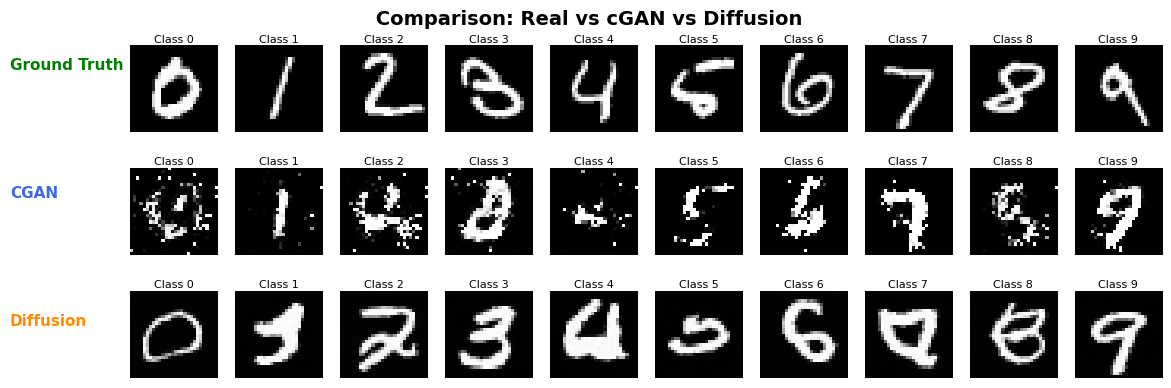

In [19]:
# ToDo: Plot evaluation image using `plot_real_cgan_diffusion`
plot_real_cgan_diffusion(real_imgs, imgs_cgan, imgs_diff, n_classes=10)

In [20]:

fid = FrechetInceptionDistance(normalize=True).to(device)
fid.reset()

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /home/student/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 278MB/s]


In [21]:
torch.cuda.empty_cache()

In [22]:
len(imgs_cgan)

10

In [23]:
# ToDo: Choose a subset of images to run the evaluation on - yeild (real_subset, cgan_subset, diff_subset)

real_subset = real_imgs[:5]
cgan_subset = imgs_cgan[:5]
diff_subset = imgs_diff[:5]

In [24]:
# ToDo: Compute cGAN FID & Diffusion FID 
cgan_fid = compute_fid(real_subset, cgan_subset, device="cuda", batch_size=128)
diff_fid = compute_fid(real_subset, diff_subset, device="cuda", batch_size=128)
print(f" cGAN FID: {cgan_fid:.2f}")
print(f"Diffusion FID: {diff_fid:.2f}")

FID fake: 100%|██████████| 1/1 [00:00<00:00, 22.55it/s]


 cGAN FID: 323.52
Diffusion FID: 229.11


In [25]:
# ToDO: Give a brief analysis of the FID score
#FID measures how closly statistical distribution of AI generated images match the distribution of reference set of real images utilizinf pre-trained inception-v3 neural network
# In this case CGAN FID is higher than diffusion FID which indicates images generated by diffusion is more close to real images from statistical distribution perspective
# This can further be attributed to the fact that images generated by cgan as displayed in an earlier output cell have more artifacts and are more incoherent and many times lacking general resemblance to original images.
# While images generated by diffusion are far from perfect but model has captured essential elements of the shape of the real images which is reflected in generated images

### Utility Evaluation (Classifier)

We’ll train a simple CNN classifier on synthetic data from each model,  
then test it on real MNIST data.

If synthetic data are realistic and diverse, the classifier should generalize well to real digits.

In [33]:
cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(cgan_gen, device=device, n_classes=10)
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(
    diff_model, device=device, n_classes=10, timesteps=200
)


In [34]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [35]:
real_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [36]:
def normalize_synthetic(imgs):
    imgs = imgs.clone()
    imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())  # [0,1]
    imgs = imgs * 2 - 1  # [-1,1]
    return imgs

cgan_imgs = normalize_synthetic(cgan_imgs)
diff_imgs = normalize_synthetic(diff_imgs)

print("Unique labels in CGAN:", torch.unique(cgan_labels))
print("Unique labels in Diffusion:", torch.unique(diff_labels))

Unique labels in CGAN: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Unique labels in Diffusion: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [37]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(model, loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / len(loader):.4f}")
    return model

In [38]:
cgan_ds = TensorDataset(cgan_imgs, cgan_labels)
diff_ds = TensorDataset(diff_imgs, diff_labels)


cgan_loader = DataLoader(cgan_ds, batch_size=128, shuffle=True)
diff_loader = DataLoader(diff_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(real_data, batch_size=256, shuffle=False)

def test_accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return correct / total

In [39]:

cnn_cgan = train_classifier(SimpleCNN().to(device), cgan_loader, epochs=20)
cnn_diff = train_classifier(SimpleCNN().to(device), diff_loader, epochs=20)

cgan_acc = test_accuracy(cnn_cgan, test_loader)
diff_acc = test_accuracy(cnn_diff, test_loader)

print(f"Classifier trained on cGAN data → Test accuracy: {cgan_acc:.3f}")
print(f"Classifier trained on Diffusion data → Test accuracy: {diff_acc:.3f}")

Epoch 1: loss = 2.3050
Epoch 2: loss = 2.2425
Epoch 3: loss = 2.1331
Epoch 4: loss = 1.9636
Epoch 5: loss = 1.7358
Epoch 6: loss = 1.4365
Epoch 7: loss = 1.0709
Epoch 8: loss = 0.6923
Epoch 9: loss = 0.3768
Epoch 10: loss = 0.1853
Epoch 11: loss = 0.0727
Epoch 12: loss = 0.0296
Epoch 13: loss = 0.0096
Epoch 14: loss = 0.0053
Epoch 15: loss = 0.0031
Epoch 16: loss = 0.0013
Epoch 17: loss = 0.0004
Epoch 18: loss = 0.0001
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Epoch 1: loss = 2.3024
Epoch 2: loss = 2.2502
Epoch 3: loss = 2.1410
Epoch 4: loss = 1.9737
Epoch 5: loss = 1.7386
Epoch 6: loss = 1.4209
Epoch 7: loss = 1.0445
Epoch 8: loss = 0.6460
Epoch 9: loss = 0.3165
Epoch 10: loss = 0.1196
Epoch 11: loss = 0.0379
Epoch 12: loss = 0.0104
Epoch 13: loss = 0.0028
Epoch 14: loss = 0.0007
Epoch 15: loss = 0.0002
Epoch 16: loss = 0.0001
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.345
Cla

In [41]:
def train_synthetic():
    cnn_cgan = train_classifier(SimpleCNN().to(device), cgan_loader, epochs=20)
    cnn_diff = train_classifier(SimpleCNN().to(device), diff_loader, epochs=20)

    cgan_acc = test_accuracy(cnn_cgan, test_loader)
    diff_acc = test_accuracy(cnn_diff, test_loader)

    print(f"Classifier trained on cGAN data → Test accuracy: {cgan_acc:.3f}")
    print(f"Classifier trained on Diffusion data → Test accuracy: {diff_acc:.3f}")

In [42]:
train_synthetic()

Epoch 1: loss = 2.3006
Epoch 2: loss = 2.2215
Epoch 3: loss = 2.0662
Epoch 4: loss = 1.8402
Epoch 5: loss = 1.5377
Epoch 6: loss = 1.1814
Epoch 7: loss = 0.7764
Epoch 8: loss = 0.4239
Epoch 9: loss = 0.1766
Epoch 10: loss = 0.0606
Epoch 11: loss = 0.0165
Epoch 12: loss = 0.0046
Epoch 13: loss = 0.0013
Epoch 14: loss = 0.0004
Epoch 15: loss = 0.0001
Epoch 16: loss = 0.0000
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Epoch 1: loss = 2.2989
Epoch 2: loss = 2.2120
Epoch 3: loss = 2.0452
Epoch 4: loss = 1.8119
Epoch 5: loss = 1.4855
Epoch 6: loss = 1.0923
Epoch 7: loss = 0.6749
Epoch 8: loss = 0.3324
Epoch 9: loss = 0.1316
Epoch 10: loss = 0.0392
Epoch 11: loss = 0.0130
Epoch 12: loss = 0.0033
Epoch 13: loss = 0.0008
Epoch 14: loss = 0.0002
Epoch 15: loss = 0.0001
Epoch 16: loss = 0.0000
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.391
Cla

In [43]:
train_synthetic()

Epoch 1: loss = 2.3006
Epoch 2: loss = 2.2243
Epoch 3: loss = 2.0861
Epoch 4: loss = 1.8774
Epoch 5: loss = 1.5889
Epoch 6: loss = 1.2141
Epoch 7: loss = 0.7937
Epoch 8: loss = 0.4298
Epoch 9: loss = 0.1865
Epoch 10: loss = 0.0685
Epoch 11: loss = 0.0210
Epoch 12: loss = 0.0078
Epoch 13: loss = 0.0030
Epoch 14: loss = 0.0009
Epoch 15: loss = 0.0002
Epoch 16: loss = 0.0001
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Epoch 1: loss = 2.3060
Epoch 2: loss = 2.2369
Epoch 3: loss = 2.1117
Epoch 4: loss = 1.9221
Epoch 5: loss = 1.6514
Epoch 6: loss = 1.3034
Epoch 7: loss = 0.8990
Epoch 8: loss = 0.5118
Epoch 9: loss = 0.2283
Epoch 10: loss = 0.0823
Epoch 11: loss = 0.0246
Epoch 12: loss = 0.0067
Epoch 13: loss = 0.0018
Epoch 14: loss = 0.0005
Epoch 15: loss = 0.0001
Epoch 16: loss = 0.0000
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.365
Cla

In [44]:
train_synthetic()

Epoch 1: loss = 2.3048
Epoch 2: loss = 2.2500
Epoch 3: loss = 2.1555
Epoch 4: loss = 2.0096
Epoch 5: loss = 1.8112
Epoch 6: loss = 1.5464
Epoch 7: loss = 1.2380
Epoch 8: loss = 0.8815
Epoch 9: loss = 0.5555
Epoch 10: loss = 0.3002
Epoch 11: loss = 0.1470
Epoch 12: loss = 0.0580
Epoch 13: loss = 0.0217
Epoch 14: loss = 0.0087
Epoch 15: loss = 0.0035
Epoch 16: loss = 0.0014
Epoch 17: loss = 0.0006
Epoch 18: loss = 0.0003
Epoch 19: loss = 0.0001
Epoch 20: loss = 0.0001
Epoch 1: loss = 2.3043
Epoch 2: loss = 2.2299
Epoch 3: loss = 2.0981
Epoch 4: loss = 1.9019
Epoch 5: loss = 1.6238
Epoch 6: loss = 1.2692
Epoch 7: loss = 0.8678
Epoch 8: loss = 0.4868
Epoch 9: loss = 0.2091
Epoch 10: loss = 0.0734
Epoch 11: loss = 0.0197
Epoch 12: loss = 0.0054
Epoch 13: loss = 0.0016
Epoch 14: loss = 0.0005
Epoch 15: loss = 0.0001
Epoch 16: loss = 0.0000
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.358
Cla

In [45]:
train_synthetic()

Epoch 1: loss = 2.3037
Epoch 2: loss = 2.2332
Epoch 3: loss = 2.0977
Epoch 4: loss = 1.9081
Epoch 5: loss = 1.6450
Epoch 6: loss = 1.3234
Epoch 7: loss = 0.9579
Epoch 8: loss = 0.5969
Epoch 9: loss = 0.3061
Epoch 10: loss = 0.1598
Epoch 11: loss = 0.1107
Epoch 12: loss = 0.0187
Epoch 13: loss = 0.0156
Epoch 14: loss = 0.0143
Epoch 15: loss = 0.0034
Epoch 16: loss = 0.0008
Epoch 17: loss = 0.0003
Epoch 18: loss = 0.0002
Epoch 19: loss = 0.0002
Epoch 20: loss = 0.0001
Epoch 1: loss = 2.3052
Epoch 2: loss = 2.2302
Epoch 3: loss = 2.1107
Epoch 4: loss = 1.9281
Epoch 5: loss = 1.6803
Epoch 6: loss = 1.3630
Epoch 7: loss = 0.9981
Epoch 8: loss = 0.6195
Epoch 9: loss = 0.3111
Epoch 10: loss = 0.1261
Epoch 11: loss = 0.0426
Epoch 12: loss = 0.0131
Epoch 13: loss = 0.0038
Epoch 14: loss = 0.0012
Epoch 15: loss = 0.0004
Epoch 16: loss = 0.0002
Epoch 17: loss = 0.0001
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.350
Cla

In [46]:
train_synthetic()

Epoch 1: loss = 2.3074
Epoch 2: loss = 2.2329
Epoch 3: loss = 2.1012
Epoch 4: loss = 1.9042
Epoch 5: loss = 1.6361
Epoch 6: loss = 1.2971
Epoch 7: loss = 0.9152
Epoch 8: loss = 0.5464
Epoch 9: loss = 0.2624
Epoch 10: loss = 0.1045
Epoch 11: loss = 0.0348
Epoch 12: loss = 0.0108
Epoch 13: loss = 0.0033
Epoch 14: loss = 0.0011
Epoch 15: loss = 0.0004
Epoch 16: loss = 0.0002
Epoch 17: loss = 0.0001
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Epoch 1: loss = 2.3050
Epoch 2: loss = 2.2287
Epoch 3: loss = 2.0949
Epoch 4: loss = 1.8933
Epoch 5: loss = 1.6090
Epoch 6: loss = 1.2507
Epoch 7: loss = 0.8433
Epoch 8: loss = 0.4633
Epoch 9: loss = 0.1984
Epoch 10: loss = 0.0664
Epoch 11: loss = 0.0177
Epoch 12: loss = 0.0047
Epoch 13: loss = 0.0015
Epoch 14: loss = 0.0005
Epoch 15: loss = 0.0002
Epoch 16: loss = 0.0001
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.401
Cla